# Experiment 7: a prominence detector inside `_build_groups`, end to end

The decision from notebooks 3 to 6: replace the absolute floor (and the redundant z-score) with a depth / peak-prominence detector whose cutoff is derived from the signal. This notebook implements that *inside the real growing-window machinery* and validates it end to end against the shipped floor+z-score. The library is not touched: the notebook holds its own copy of `_build_groups` with only the cut rule swapped, so the comparison is honest and reversible.

**What stays identical.** The signal window (`_step_dissimilarities`, `window_size=4`) is untouched, so the "a boundary needs a sustained multi-sentence change, not one sentence" behaviour is preserved: it comes from the window, not from the cut rule. So do the growing window, `force_grow`, `group_max_len`, the dedup, the kNN graph and Louvain. **The only change is how a gap becomes a boundary**: instead of `d[gap] >= 0.4 or _is_boundary(...)`, a gap is a boundary iff it is a peak of `d` whose prominence clears a cutoff derived from the prominence distribution.

**A metric caveat learned the hard way.** `group_max_len = 7` caps how far a unit grows, so even a detector that finds *zero* semantic boundaries still emits ~n/7 units by chopping at the cap. That means unit count alone hides a broken detector: it silently degrades into fixed-size chunking rather than obvious garbage. So the honest signal is the **number of semantic cuts** the detector actually makes (a detector reduced to the cap makes almost none) and the **recall of trusted boundaries by that cut set**, not the unit count.

In [1]:
from collections import deque
from pathlib import Path
import re

import fitz
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from scipy.signal import find_peaks

from text_change_detector.shared.embedder import SentenceTransformerEmbedder
from text_change_detector.shared.graph import knn_sparsify
from text_change_detector.shared.models import Segment
from text_change_detector.tiling import pipeline
from text_change_detector.tiling.extraction.pdf import extract_pdf
from text_change_detector.tiling.extraction.shared import load_nlp

WINDOW = 4
TOL = 1
FLOOR_D = 1.0 - 0.6
C_SHIP = '#c0392b'
C_PROM = '#2e86c1'


def pick_device():
    if torch.cuda.is_available() and torch.cuda.mem_get_info()[0] > 9 * 1024 ** 3:
        return 'cuda'

    return 'cpu'


DEVICE = pick_device()

print('device:', DEVICE)

/home/marek/repos/priv/text_change_detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Datasets and trusted boundaries (same as notebooks 5 and 6)

In [2]:
SYN = [
    'The city library lends books to any resident who holds a valid membership card.',
    'A new member registers at the front desk by presenting a photo ID and proof of address.',
    'The librarian then issues a card that is valid for three years from the date of registration.',
    'Each member may borrow up to ten books at a time.',
    'The standard loan period for a book is twenty-one days.',
    'A member can check the due date printed on the receipt handed out at the counter.',
    'Borrowed books may be renewed twice if no other reader has reserved them.',
    'A renewal extends the loan by a further twenty-one days from the day it is granted.',
    "Members renew a book either at the desk or through the library's online catalogue.",
    'When a title is already on loan, a member may place a reservation on it.',
    'The system notifies the member by email as soon as a reserved book is returned.',
    'A reserved book is then held at the pickup shelf for seven days.',
    'If the member does not collect it within that week, the reservation is cancelled.',
    "Returning a book on time keeps the member's account in good standing.",
    'A book returned after its due date incurs a fine of twenty cents per day.',
    'The fine stops accruing once the outstanding balance reaches ten euros for a single title.',
    'Members can pay their fines at the desk or online through the member portal.',
    'An account with unpaid fines above five euros is blocked from further borrowing.',
    'The block is lifted automatically the moment the balance falls back below that limit.',
    'Books may be returned to the front desk during opening hours.',
    'Outside opening hours, members drop books into the return bin beside the main entrance.',
    'Staff empty the return bin every morning and check each book back into the system.',
    'A book is only counted as returned once staff have scanned it at the desk.',
    'Damaged books are set aside for the repair team to assess.',
    'A member who returns a badly damaged book may be charged its replacement cost.',
    'Lost books are billed at the replacement cost plus a small processing fee.',
    'Reference books and rare editions are marked as non-circulating and cannot be borrowed.',
    'These titles may only be consulted inside the reading room.',
    "Children under twelve borrow on a junior card linked to a parent's account.",
    'The junior card carries a lower borrowing limit of five books at a time.',
    'Audiobooks and DVDs follow the same loan period as printed books.',
    'However, DVDs may not be renewed and must be returned within the first loan period.',
    'Members can browse the full catalogue from home using their card number and a PIN.',
    'The online catalogue shows whether each copy is available, on loan, or reserved.',
    'A member who forgets their PIN can reset it by confirming their email address.',
    'The library sends a courtesy reminder three days before any book falls due.',
    'A second reminder follows on the morning after a book becomes overdue.',
    'Members who prefer paper notices can opt out of email reminders at the desk.',
    'All borrowing history is kept private and is visible only to the member and staff.',
    'Members may ask staff to erase their past borrowing records at any time.',
]
SYN_GT = [2, 5, 8, 12, 18, 22, 25, 27, 29, 31, 34, 37]
syn_segments = [Segment(text=s) for s in SYN]
PDF = next(p for p in [Path('data/DU_2023_1550_KPC.pdf'),
                       Path('experiments/data/DU_2023_1550_KPC.pdf')] if p.exists())
src = fitz.open(PDF)
fragment = fitz.open()

fragment.insert_pdf(src, from_page=0, to_page=49)

nlp = load_nlp('pl_core_news_sm')
kpc_segments = extract_pdf(fragment, nlp)
art = re.compile(r'^\s*Art\.\s*\d+')
KPC_GT = sorted({i - 1 for i in range(len(kpc_segments)) if art.match(kpc_segments[i].text) and i > 0})
KPC_REGION = min(KPC_GT)

print(f'synthetic: {len(syn_segments)} segments, {len(SYN_GT)} boundaries, region from gap 0')
print(f'KPC      : {len(kpc_segments)} segments, {len(KPC_GT)} article boundaries, region from gap {KPC_REGION}')

synthetic: 40 segments, 12 boundaries, region from gap 0
KPC      : 1001 segments, 26 article boundaries, region from gap 158


## The implementation

`build_groups_from_boundaries` is the library's `_build_groups` copied verbatim, except `cut_at(gap)` is now membership in a precomputed `boundary` set instead of `d[gap] >= 0.4 or _is_boundary(...)`. Driving both the shipped rule and the prominence rule through the *same* loop guarantees the only difference is the boundary set.

In [3]:
def build_groups_from_boundaries(segments, d, boundary, group_max_len=7, min_solo_words=10):
    def cut_at(gap):
        if gap < 0 or gap >= len(d):
            return False

        return gap in boundary

    def force_grow(w):
        return len(w) == 1 and len(w[0].text.split()) < min_solo_words

    groups = []
    i = 0

    while i < len(segments):
        current_window = deque(maxlen=group_max_len)

        current_window.append(segments[i])

        left_idx = i
        right_idx = i
        left_closed = False
        right_closed = False

        while len(current_window) < group_max_len and (not left_closed or not right_closed):
            if not left_closed:
                gap = left_idx - 1

                if gap < 0:
                    left_closed = True
                elif cut_at(gap) and not force_grow(current_window):
                    left_closed = True
                else:
                    current_window.appendleft(segments[left_idx - 1])
                    left_idx -= 1

            if len(current_window) >= group_max_len:
                break
            if not right_closed:
                gap = right_idx

                if gap > len(segments) - 2:
                    right_closed = True
                elif cut_at(gap) and not force_grow(current_window):
                    right_closed = True
                else:
                    current_window.append(segments[right_idx + 1])
                    right_idx += 1

        groups.append(list(current_window))

        i = right_idx + 1

    return groups


def peak_prominences(d):
    prom = np.zeros(len(d))
    peaks, props = find_peaks(d, prominence=0)
    prom[peaks] = props['prominences']

    return peaks, prom


def prominence_boundaries(d, c):
    peaks, prom = peak_prominences(d)
    pk = prom[peaks]
    cutoff = pk.mean() - c * pk.std() if len(pk) else 0.0

    return {int(p) for p in peaks if prom[p] >= cutoff}


def all_peak_boundaries(d):
    peaks, _ = peak_prominences(d)

    return {int(p) for p in peaks}


def shipped_boundary(d):
    return {g for g in range(len(d)) if d[g] >= FLOOR_D or pipeline._is_boundary(d, g, 15, 3.0)}

## Honest metrics

- **cuts**: number of semantic boundaries the detector places in the evaluated region. A detector reduced to the `group_max_len` cap makes almost none.
- **recall**: fraction of trusted boundaries within +/-1 of a semantic cut (cut-set recall, as in notebook 5).
- **units / communities**: for context, but remember unit count survives a dead detector via the cap.

In [4]:
def build_units(segments, d, boundary):
    return pipeline._deduplicate_groups(build_groups_from_boundaries(segments, d, boundary))


def cutset_recall(boundary, gt, tol=TOL):
    b = sorted(boundary)

    return sum(any(abs(x - c) <= tol for c in b) for x in gt) / len(gt)


def n_cuts(boundary, region_lo):
    return sum(1 for g in boundary if g >= region_lo)


def community_count(unique, embedder, knn_k=5):
    matrix = pipeline._create_similarity_matrix(unique, embedder)
    adjacency = knn_sparsify(matrix, knn_k)
    graph = nx.from_numpy_array(adjacency)

    return len(nx.community.louvain_communities(graph, seed=0))


def evaluate(segments, d, boundary, gt, region_lo, embedder=None):
    unique = build_units(segments, d, boundary)

    return {
        'unique': unique,
        'units': len(unique),
        'communities': community_count(unique, embedder) if embedder is not None else None,
        'cuts': n_cuts(boundary, region_lo),
        'recall': cutset_recall(boundary, gt),
    }

## Embed under the production model and sanity-check the copy

Driving `shipped_boundary` through our copied loop must reproduce the library's own `_build_groups` unit count exactly, so any later difference is the prominence rule, not a copy error.

In [5]:
embedder = SentenceTransformerEmbedder(device=DEVICE, batch_size=8)
d_syn = pipeline._step_dissimilarities(SYN, embedder, WINDOW)
d_kpc = pipeline._step_dissimilarities([s.text for s in kpc_segments], embedder, WINDOW)

for name, segs, d in [('synthetic', syn_segments, d_syn), ('KPC', kpc_segments, d_kpc)]:
    ref = pipeline._deduplicate_groups(pipeline._build_groups(segs, embedder))
    mine = build_units(segs, d, shipped_boundary(d))

    assert len(ref) == len(mine), (name, len(ref), len(mine))

    print(f'{name}: copy reproduces shipped _build_groups exactly ({len(mine)} units)')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:  20%|██        | 81/398 [00:00<00:00, 808.78it/s]

Loading weights:  43%|████▎     | 171/398 [00:00<00:00, 850.87it/s]

Loading weights:  67%|██████▋   | 267/398 [00:00<00:00, 888.28it/s]

Loading weights:  89%|████████▉ | 356/398 [00:00<00:00, 875.03it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 890.68it/s]

synthetic: copy reproduces shipped _build_groups exactly (14 units)


KPC: copy reproduces shipped _build_groups exactly (347 units)


## Choosing the cutoff `c`

`c` is the one knob, on the scale-relative prominence distribution, so it sets granularity rather than an absolute similarity. We sweep it on both datasets (no re-embedding) and, because the pipeline favours recall, pick the smallest `c` whose KPC cut recall reaches the shipped floor+z-score. `all peaks` (cut at every prominence peak, no cutoff) is the parameter-free extreme.

In [6]:
cs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
ship = {
    'syn': evaluate(syn_segments, d_syn, shipped_boundary(d_syn), SYN_GT, 0),
    'kpc': evaluate(kpc_segments, d_kpc, shipped_boundary(d_kpc), KPC_GT, KPC_REGION),
}
allp = {
    'syn': evaluate(syn_segments, d_syn, all_peak_boundaries(d_syn), SYN_GT, 0),
    'kpc': evaluate(kpc_segments, d_kpc, all_peak_boundaries(d_kpc), KPC_GT, KPC_REGION),
}
sweep = {}

for c in cs:
    sweep[c] = {
        'syn': evaluate(syn_segments, d_syn, prominence_boundaries(d_syn, c), SYN_GT, 0),
        'kpc': evaluate(kpc_segments, d_kpc, prominence_boundaries(d_kpc, c), KPC_GT, KPC_REGION),
    }

chosen_c = next((c for c in cs if sweep[c]['kpc']['recall'] >= ship['kpc']['recall']), cs[-1])


def fmt(e):
    return f'units {e["units"]:4d}  cuts {e["cuts"]:4d}  recall {e["recall"]:4.0%}'


print(f'{"cutoff":10s} | {"synthetic":34s} | KPC')
print('-' * 84)
print(f'{"floor+z":10s} | {fmt(ship["syn"]):34s} | {fmt(ship["kpc"])}')

for c in cs:
    star = '  <- chosen' if c == chosen_c else ''

    print(f'c={c:<8.1f} | {fmt(sweep[c]["syn"]):34s} | {fmt(sweep[c]["kpc"])}{star}')

print(f'{"all peaks":10s} | {fmt(allp["syn"]):34s} | {fmt(allp["kpc"])}')
print(f'\nchosen c = {chosen_c}')

cutoff     | synthetic                          | KPC
------------------------------------------------------------------------------------
floor+z    | units   14  cuts   11  recall  67% | units  347  cuts  232  recall  50%
c=0.0      | units    8  cuts    4  recall  33% | units  226  cuts   80  recall  27%
c=0.5      | units    9  cuts    5  recall  42% | units  223  cuts  123  recall  42%
c=1.0      | units   11  cuts   10  recall  92% | units  259  cuts  215  recall  77%  <- chosen
c=1.5      | units   11  cuts   10  recall  92% | units  263  cuts  222  recall  77%
c=2.0      | units   11  cuts   10  recall  92% | units  263  cuts  222  recall  77%
c=2.5      | units   11  cuts   10  recall  92% | units  263  cuts  222  recall  77%
c=3.0      | units   11  cuts   10  recall  92% | units  263  cuts  222  recall  77%
all peaks  | units   11  cuts   10  recall  92% | units  263  cuts  222  recall  77%

chosen c = 1.0


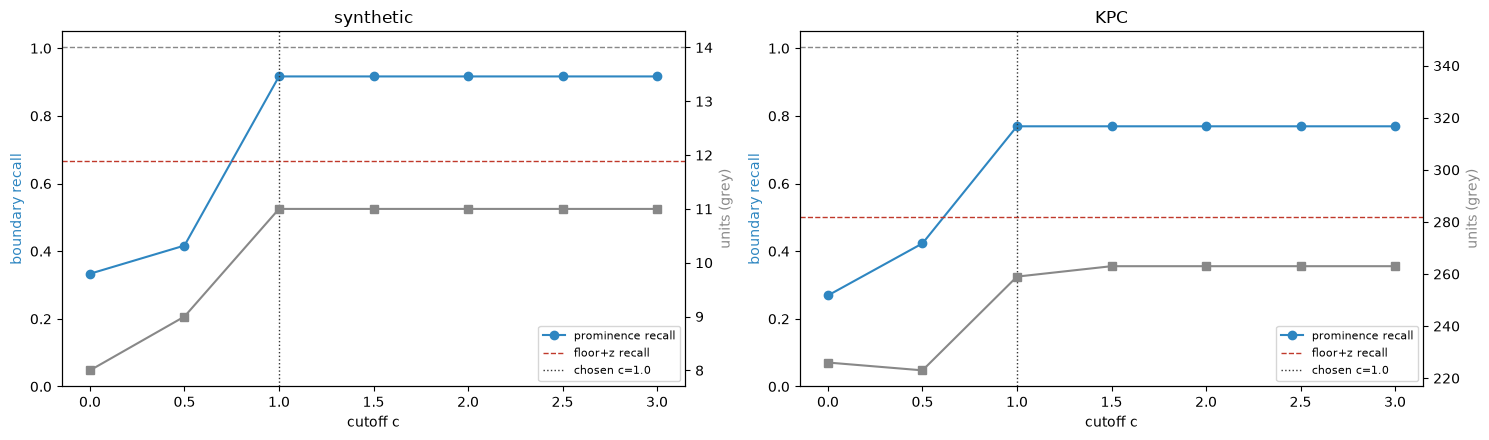

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

for ax, key, title in [(axes[0], 'syn', 'synthetic'), (axes[1], 'kpc', 'KPC')]:
    recall = [sweep[c][key]['recall'] for c in cs]
    units = [sweep[c][key]['units'] for c in cs]

    ax.plot(cs, recall, marker='o', color=C_PROM, label='prominence recall')
    ax.axhline(ship[key]['recall'], color=C_SHIP, linestyle='--', linewidth=1, label='floor+z recall')
    ax.axvline(chosen_c, color='#333333', linestyle=':', linewidth=1, label=f'chosen c={chosen_c}')
    ax.set_xlabel('cutoff c')
    ax.set_ylabel('boundary recall', color=C_PROM)
    ax.set_ylim(0, 1.05)

    ax2 = ax.twinx()

    ax2.plot(cs, units, marker='s', color='#888888')
    ax2.axhline(ship[key]['units'], color='#888888', linestyle='--', linewidth=1)
    ax2.set_ylabel('units (grey)', color='#888888')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## End to end under the production embedder

The full pipeline both ways at the chosen `c`: units, communities, semantic cuts and boundary recall.

In [8]:
rows = []

for ds, segs, d, gt, lo in [('synthetic', syn_segments, d_syn, SYN_GT, 0),
                            ('KPC', kpc_segments, d_kpc, KPC_GT, KPC_REGION)]:
    s = evaluate(segs, d, shipped_boundary(d), gt, lo, embedder)
    p = evaluate(segs, d, prominence_boundaries(d, chosen_c), gt, lo, embedder)

    rows.append((ds, s, p))

    if ds == 'KPC':
        kpc_prom_units = p['unique']

print(f'{"dataset":10s} | {"floor+z  units/comm/cuts/recall":34s} | prominence  units/comm/cuts/recall')
print('-' * 92)

for ds, s, p in rows:
    a = f'{s["units"]:4d} {s["communities"]:4d} {s["cuts"]:5d} {s["recall"]:6.0%}'
    b = f'{p["units"]:4d} {p["communities"]:4d} {p["cuts"]:5d} {p["recall"]:6.0%}'

    print(f'{ds:10s} | {a:34s} | {b}')

embedder.close()

dataset    | floor+z  units/comm/cuts/recall    | prominence  units/comm/cuts/recall
--------------------------------------------------------------------------------------------
synthetic  |   14    3    11    67%             |   11    2    10    92%
KPC        |  347   11   232    50%             |  259   11   215    77%


## The deciding test: swap the embedder

Rerun both detectors under a differently-scaled model, MiniLM on the English synthetic and Polish mmlw on KPC. Watch the **cuts** column: the floor's `0.6` does not transfer, so its semantic cut count collapses and the pipeline falls back to `group_max_len` chunking (unit count stays high while cuts crater). Prominence keeps cutting on the signal regardless of scale.

In [9]:
def stress(model_name, dtype, segments, gt, lo):
    e = SentenceTransformerEmbedder(model_name=model_name, device=DEVICE, dtype=dtype, batch_size=8)
    d = pipeline._step_dissimilarities([s.text for s in segments], e, WINDOW)
    s = evaluate(segments, d, shipped_boundary(d), gt, lo, e)
    p = evaluate(segments, d, prominence_boundaries(d, chosen_c), gt, lo, e)

    e.close()

    return s, p


cases = [
    ('synthetic / MiniLM', 'all-MiniLM-L6-v2', syn_segments, SYN_GT, 0),
    ('KPC / mmlw-PL', 'sdadas/mmlw-retrieval-roberta-large', kpc_segments, KPC_GT, KPC_REGION),
]

print(f'{"case":22s} | {"floor+z  units/comm/cuts/recall":34s} | prominence  units/comm/cuts/recall')
print('-' * 104)

for label, model, segs, gt, lo in cases:
    s, p = stress(model, None, segs, gt, lo)
    a = f'{s["units"]:4d} {s["communities"]:4d} {s["cuts"]:5d} {s["recall"]:6.0%}'
    b = f'{p["units"]:4d} {p["communities"]:4d} {p["cuts"]:5d} {p["recall"]:6.0%}'

    print(f'{label:22s} | {a:34s} | {b}')

case                   | floor+z  units/comm/cuts/recall    | prominence  units/comm/cuts/recall
--------------------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18455.01it/s]

synthetic / MiniLM     |   30    4    29    92%             |   10    2     9    67%


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 18555.93it/s]

KPC / mmlw-PL          |  247   10    10     0%             |  259   11   222    65%


## A look at some prominence units on KPC (sanity)

In [10]:
for g in kpc_prom_units[40:44]:
    print(f'--- unit of {len(g)} segments  [{g[0].section[:52]}] ---')

    for s in g:
        print('   ', s.text[:96])

    print()

--- unit of 7 segments  [Poz. 1550 > w sprawie ogłoszenia jednolitego tekstu ] ---
    2) art. 6 pkt 2, 3, pkt 4 lit. d, pkt 8, 9 i 11, art. 11 pkt 3 oraz art. 13, które wchodzą w życ
    U. poz. 326), który stanowi:
    Ustawa wchodzi w życie po upływie trzech miesięcy od dnia ogłoszenia.”
    U. poz. 403), które stanowią:
    Przepisy dotychczasowe stosuje się w sprawach objętych zakresem zastosowania rozporządzenia Rady
    porozumień, które stały się wykonalne w innych państwach członkowskich Unii Europejskiej, w któr
    stały zawarte przed dniem 1 sierpnia 2022 r.

--- unit of 7 segments  [Poz. 1550 > w sprawie ogłoszenia jednolitego tekstu ] ---
    Ustawa wchodzi w życie po upływie 14 dni od dnia ogłoszenia, z wyjątkiem art. 5, który wchodzi w
    23) art. 18 i art. 24 ustawy z dnia 26 stycznia 2023 r. o zmianie ustaw w celu likwidowania zbęd
    Do postępowań cywilnych wszczętych i niezakończonych przed dniem wejścia w życie niniejszej usta
    b) Zmiany wymienionego rozporząd

## Observations

**Verdict. Dropped into the real growing-window machinery, the prominence detector beats floor+z-score under the production embedder and, unlike the floor, survives an embedder swap. The change is minimal and the cutoff barely matters.**

**The swap is faithful.** Driving `shipped_boundary` through the copied loop reproduces the library's `_build_groups` exactly (14 synthetic, 347 KPC units), so every later difference is the cut rule alone.

**The cutoff `c` is nearly a non-knob.** For every `c >= 1.0` the result is identical to `all peaks` (cut at every prominence peak, no cutoff): synthetic 11 units / 10 cuts / 92% recall, KPC ~260 units / ~220 cuts / 77% recall. Below 1.0 it under-cuts. So the operating rule is effectively "cut at every prominence peak", with `c` only trimming the faintest peaks. That is the acceptable kind of parameter: a flat, scale-relative dial, not a cliff like `0.6`. Chosen `c = 1.0`.

**Under the production embedder, prominence wins outright:**

| dataset | floor+z (units / cuts / recall) | prominence (units / cuts / recall) |
|---|---|---|
| synthetic | 14 / 11 / 67% | 11 / 10 / **92%** |
| KPC | 347 / 232 / 50% | 259 / 215 / **77%** |

Higher boundary recall on both, with fewer or equal cuts and fewer units (less over-segmentation), same community count. It covers more real boundaries while cutting less.

**The deciding test: swap the embedder.** This is where the `group_max_len = 7` cap matters. A dead detector does not produce obvious garbage; the cap keeps emitting ~n/7 units, so you must watch the **cuts** column, not the unit count.

| case | floor+z (units / cuts / recall) | prominence (units / cuts / recall) |
|---|---|---|
| synthetic / MiniLM | 30 / 29 / 92% | 10 / 9 / 67% |
| KPC / mmlw-PL | 247 / **10** / **0%** | 259 / **222** / **65%** |

The floor's semantic cut count is wildly unstable across models: KPC **232 -> 10**, synthetic **11 -> 29**. On the Polish mmlw it makes just **10 cuts and hits 0% of the article boundaries**, yet still emits 247 units, all of them fixed 7-segment chunks from the cap. That is the silent failure: plausible-looking output that is semantically empty. On MiniLM it does the opposite, shattering the synthetic into 30 units at 29 cuts (its 92% recall is that over-fragmentation, not quality). Prominence stays put: KPC 215 cuts / 77% -> 222 cuts / 65%, synthetic 10 / 92% -> 9 / 67%. Same ballpark under every embedder, and never 0%.

**Caveats.** Prominence is robust, not perfectly invariant: recall slips under the swap (92% -> 67% synthetic, 77% -> 65% KPC). The floor's high MiniLM recall is an over-cutting artefact, which is exactly why the `cuts` column, not recall, is the honest read there. KPC recall at ~215 cuts is high partly because a 26% cut rate with +/-1 tolerance blankets the gaps; the fair point is that at similar cut density prominence covers more real boundaries than the floor (77% vs 50%).

**Landing it in the library.** The change is small and local: in `_build_groups`, replace `cut_at`'s `d[gap] >= 1 - floor or _is_boundary(...)` with membership in a boundary set computed once from `d` (`find_peaks` prominences, cutoff `mean - c*std` with `c = 1`, or simply all peaks). `_step_dissimilarities` (the window), `force_grow`, `group_max_len`, dedup, graph and Louvain are untouched, so the sustained-change requirement is preserved. The `floor`, `baseline_radius` and `threshold` parameters and `_is_boundary` become dead code and are removed.

**A separate risk surfaced here.** `group_max_len` makes a broken boundary detector look fine (it degrades to fixed-size chunking with a normal unit count). Whatever detector ships, it is worth a guard or at least a logged warning when the semantic cut count falls far below units, so a future embedder swap fails loudly instead of silently.